In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('telco.csv')

df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,City,Zip Code,Latitude,Longitude,Population,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,Los Angeles,90022,34.023810,-118.156582,68701,Q3,No,0,1,NaN,No,0.00,No,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,Los Angeles,90063,34.044271,-118.185237,55668,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,Los Angeles,90065,34.108833,-118.229715,47534,Q3,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,52,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,Inglewood,90303,33.936291,-118.332639,27778,Q3,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,12,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,Whittier,90602,33.972119,-118.020188,26265,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Fiber Optic,14,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [5]:
print(df.shape)

df.info()

(7043, 50)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-n

In [6]:
df.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
Under 30,0
Senior Citizen,0
Married,0
Dependents,0
Number of Dependents,0
Country,0
State,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Churn Label"].value_counts()

,count
Churn Label,
No,5174
Yes,1869


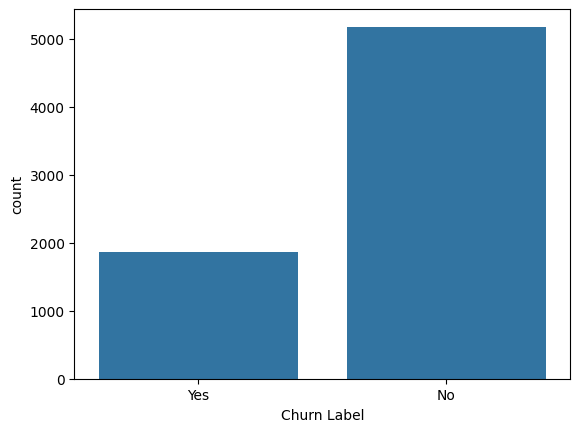

In [9]:
sns.countplot(x="Churn Label", data=df)
plt.show()

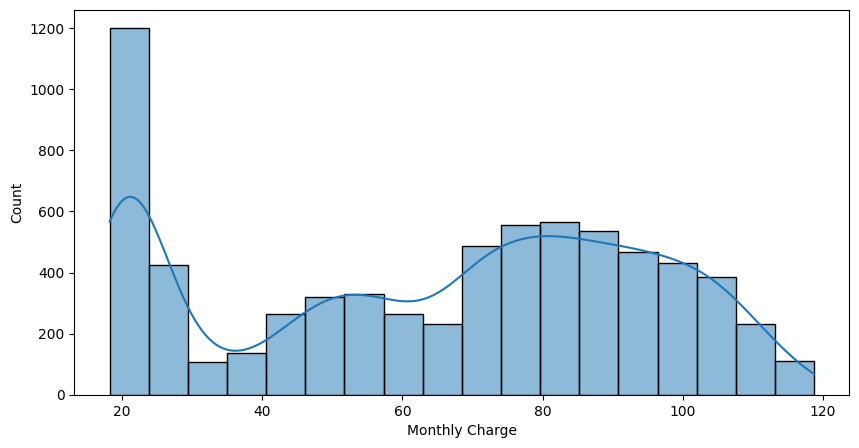

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(df["Monthly Charge"], kde=True)

plt.show()

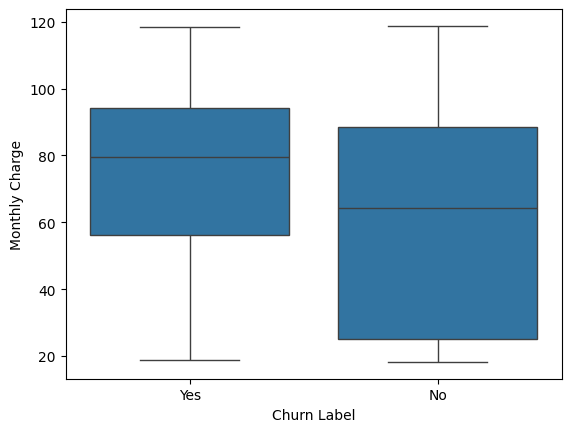

In [11]:
sns.boxplot(
    x="Churn Label",
    y="Monthly Charge",
    data=df
)

plt.show()

# Data Preprocessing

In [12]:
df.isnull().sum().sort_values(ascending=False)

,0
Churn Reason,5174
Churn Category,5174
Offer,3877
Internet Type,1526
Senior Citizen,0
Married,0
Age,0
Under 30,0
Country,0
State,0


In [13]:
print("Jumlah duplikat:", df.duplicated().sum())

Jumlah duplikat: 0


In [14]:
drop_columns = [
    "Customer ID",
    "Customer Status",
    "Churn Category",
    "Churn Reason",
    "Churn Score",
    "CLTV",
    "Satisfaction Score",
    "City",
    "State",
    "Zip Code",
    "Latitude",
    "Longitude"
]

df = df.drop(columns=drop_columns, errors="ignore")

In [15]:
df.shape

(7043, 38)

In [16]:
print(df.columns.tolist())

['Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Country', 'Population', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Churn Label']


In [17]:
# fill missing
df["Offer"] = df["Offer"].fillna("Unknown")
df["Internet Type"] = df["Internet Type"].fillna("Unknown")

# encode target
df["Churn Label"] = df["Churn Label"].map({
    "No": 0,
    "Yes": 1
})

# X y
X = df.drop("Churn Label", axis=1)
y = df["Churn Label"]

In [18]:
df.isnull().sum().sort_values(ascending=False).head(20)

,0
Gender,0
Age,0
Under 30,0
Senior Citizen,0
Married,0
Dependents,0
Number of Dependents,0
Country,0
Population,0
Quarter,0


In [19]:
df["Offer"] = df["Offer"].fillna("Unknown")
df["Internet Type"] = df["Internet Type"].fillna("Unknown")

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             7043 non-null   object 
 1   Age                                7043 non-null   int64  
 2   Under 30                           7043 non-null   object 
 3   Senior Citizen                     7043 non-null   object 
 4   Married                            7043 non-null   object 
 5   Dependents                         7043 non-null   object 
 6   Number of Dependents               7043 non-null   int64  
 7   Country                            7043 non-null   object 
 8   Population                         7043 non-null   int64  
 9   Quarter                            7043 non-null   object 
 10  Referred a Friend                  7043 non-null   object 
 11  Number of Referrals                7043 non-null   int64

In [21]:
categorical_cols = df.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols = df.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Jumlah categorical:", len(categorical_cols))
print("Jumlah numerical:", len(numerical_cols))

Jumlah categorical: 24
Jumlah numerical: 14


## Handling Missing Values

In [22]:
df["Offer"] = df["Offer"].fillna("Unknown")
df["Internet Type"] = df["Internet Type"].fillna("Unknown")

In [23]:
df.isnull().sum().sum()

np.int64(0)

In [24]:
df["Churn Label"].value_counts()

,count
Churn Label,
0,5174
1,1869


In [25]:
X = df.drop("Churn Label", axis=1)
y = df["Churn Label"]

print(X.shape)
print(y.shape)

(7043, 37)
(7043,)


In [26]:
categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical:", len(categorical_cols))
print("Numerical:", len(numerical_cols))

Categorical: 24
Numerical: 13


In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ]
)

In [29]:
X_processed = preprocessor.fit_transform(X)

In [30]:
X_processed.shape

(7043, 67)

In [31]:
print(type(X_processed))
print(X_processed.shape)

<class 'numpy.ndarray'>
(7043, 67)


In [32]:
X = df.drop("Churn Label", axis=1)
y = df["Churn Label"]

In [33]:
categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print(len(categorical_cols))
print(len(numerical_cols))

24
13


In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ]
)

In [35]:
X_processed = preprocessor.fit_transform(X)

print(X_processed.shape)

(7043, 67)


In [36]:
print(type(X_processed))
print(X_processed.shape)
print(len(preprocessor.get_feature_names_out()))

<class 'numpy.ndarray'>
(7043, 67)
67


In [37]:
encoded_columns = preprocessor.get_feature_names_out()

X_processed_df = pd.DataFrame(
    X_processed,
    columns=encoded_columns
)

X_processed_df["Churn Label"] = y.values

X_processed_df.head()

,num__Age,num__Number of Dependents,num__Population,num__Number of Referrals,num__Tenure in Months,num__Avg Monthly Long Distance Charges,num__Avg Monthly GB Download,num__Monthly Charge,num__Total Charges,num__Total Refunds,num__Total Extra Data Charges,num__Total Long Distance Charges,num__Total Revenue,cat__Gender_Female,cat__Gender_Male,cat__Under 30_No,cat__Under 30_Yes,cat__Senior Citizen_No,cat__Senior Citizen_Yes,cat__Married_No,cat__Married_Yes,cat__Dependents_No,cat__Dependents_Yes,cat__Country_United States,cat__Quarter_Q3,cat__Referred a Friend_No,cat__Referred a Friend_Yes,cat__Offer_Offer A,cat__Offer_Offer B,cat__Offer_Offer C,cat__Offer_Offer D,cat__Offer_Offer E,cat__Offer_Unknown,cat__Phone Service_No,cat__Phone Service_Yes,cat__Multiple Lines_No,cat__Multiple Lines_Yes,cat__Internet Service_No,cat__Internet Service_Yes,cat__Internet Type_Cable,cat__Internet Type_DSL,cat__Internet Type_Fiber Optic,cat__Internet Type_Unknown,cat__Online Security_No,cat__Online Security_Yes,cat__Online Backup_No,cat__Online Backup_Yes,cat__Device Protection Plan_No,cat__Device Protection Plan_Yes,cat__Premium Tech Support_No,cat__Premium Tech Support_Yes,cat__Streaming TV_No,cat__Streaming TV_Yes,cat__Streaming Movies_No,cat__Streaming Movies_Yes,cat__Streaming Music_No,cat__Streaming Music_Yes,cat__Unlimited Data_No,cat__Unlimited Data_Yes,cat__Contract_Month-to-Month,cat__Contract_One Year,cat__Contract_Two Year,cat__Paperless Billing_No,cat__Paperless Billing_Yes,cat__Payment Method_Bank Withdrawal,cat__Payment Method_Credit Card,cat__Payment Method_Mailed Check,Churn Label
0,1.880110,-0.486835,2.201392,-0.650409,-1.278988,-1.486303,-0.612975,-0.834611,-0.988823,-0.248313,0.523411,-0.884833,-1.038299,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1
1,1.641292,0.551874,1.585200,-0.317185,-0.993743,1.676120,-0.172176,0.528063,-0.726848,-0.248313,-0.273300,-0.423221,-0.701668,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1
2,1.462179,2.629292,1.200630,-0.650409,-0.586250,-0.752828,1.542040,1.019955,-0.232929,5.523605,-0.273300,-0.643940,-0.392146,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1
3,1.880110,0.551874,0.266580,-0.317185,-0.301005,-0.207092,-0.417064,1.121324,0.103315,1.451245,-0.273300,-0.301322,-0.013720,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1
4,1.999519,0.551874,0.195046,-0.317185,0.187986,-1.076516,-0.319109,0.390134,0.259379,-0.248313,-0.273300,-0.608185,0.023728,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1


In [38]:
X_processed_df.to_csv(
    "telco_processed.csv",
    index=False
)

In [39]:
from google.colab import files

files.download("telco_processed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Machine Learning Modeling

In [40]:
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [41]:
X = X_processed_df.drop(
    "Churn Label",
    axis=1
)

y = X_processed_df["Churn Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5634, 67)
(1409, 67)


In [42]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [43]:
y_pred = rf.predict(X_test)

In [44]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.843860894251242
Precision: 0.7619047619047619
Recall   : 0.5989304812834224
F1 Score : 0.6706586826347305


In [45]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.87      0.93      0.90      1035
           1       0.76      0.60      0.67       374

    accuracy                           0.84      1409
   macro avg       0.81      0.77      0.78      1409
weighted avg       0.84      0.84      0.84      1409



In [46]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.843860894251242
Precision: 0.7619047619047619
Recall   : 0.5989304812834224
F1 Score : 0.6706586826347305


In [47]:
print(df.columns.tolist())

['Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Country', 'Population', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Churn Label']


# Kesimpulan

Model Random Forest berhasil mencapai akurasi sebesar 84,39% dalam memprediksi pelanggan yang akan churn. Nilai precision sebesar 76,19% menunjukkan bahwa sebagian besar pelanggan yang diprediksi churn memang benar-benar churn. Nilai recall sebesar 59,89% menunjukkan bahwa model masih melewatkan sebagian pelanggan churn. Secara keseluruhan model memperoleh F1-Score sebesar 67,07% yang menunjukkan performa klasifikasi yang cukup baik dan seimbang.

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

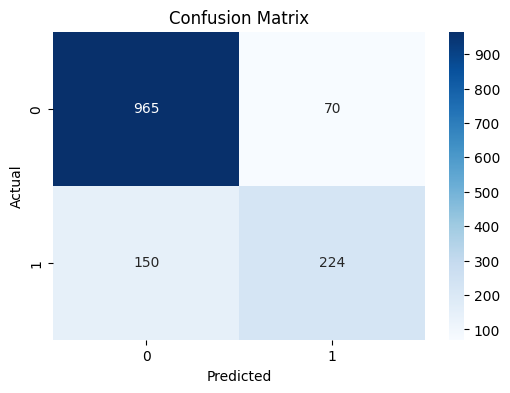

In [49]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [50]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
59,cat__Contract_Month-to-Month,0.080622
4,num__Tenure in Months,0.065743
7,num__Monthly Charge,0.061446
8,num__Total Charges,0.060854
12,num__Total Revenue,0.057230
11,num__Total Long Distance Charges,0.049032
0,num__Age,0.047906
3,num__Number of Referrals,0.046620
2,num__Population,0.045972
6,num__Avg Monthly GB Download,0.041076


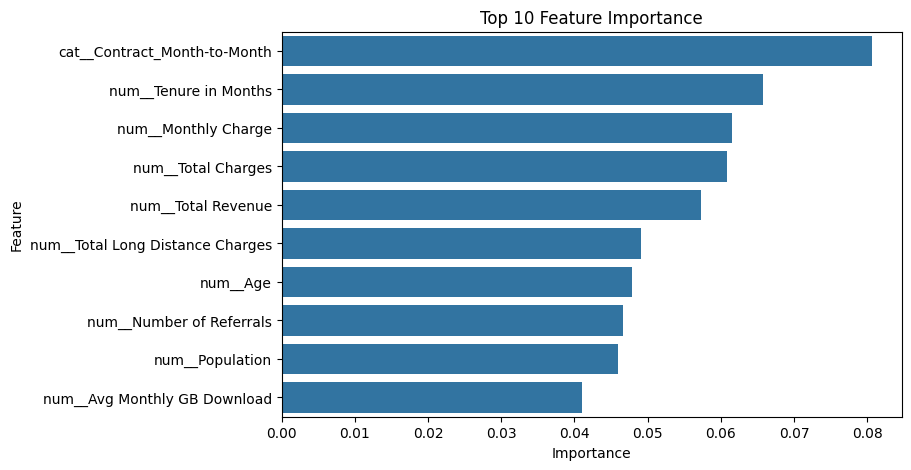

In [51]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance")
plt.show()